# Сравнительный анализ MLP и LeNet-5 на датасете MNIST

Данный проект посвящен классической задаче компьютерного зрения — распознаванию рукописных цифр. Основная цель: наглядно продемонстрировать преимущество сверточных архитектур над полносвязными сетями в задачах обработки изображений.

**Основные этапы:**
* Загрузка и предобработка данных (нормализация, создание DataLoader).
* Реализация и обучение полносвязного перцептрона (MLP).
* Реализация и обучение классической сверточной сети LeNet-5.
* Сравнительный анализ графиков метрик на валидационной выборке.

In [54]:
import os
from torchvision.datasets import MNIST
from torchvision import transforms as tfs
from torch.utils.data import DataLoader
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

import torch
from torch import nn
from torch.nn import functional as F

from torch.utils.data import TensorDataset, DataLoader
import random
from tqdm.notebook import tqdm

import copy

data_tfs = tfs.Compose([
    tfs.ToTensor(),
    tfs.Normalize((0.5), (0.5))
])

root = './'
train_dataset_MNIST = MNIST(root, train=True,  transform=data_tfs, download=True)
val_dataset_MNIST  = MNIST(root, train=False, transform=data_tfs, download=True)

train_dataloader_MNIST = DataLoader(train_dataset_MNIST, batch_size=128, shuffle=True)
valid_dataloader_MNIST = DataLoader(val_dataset_MNIST, batch_size=128, shuffle=False)

# Далее будем использовать словарь из загрузчиков
loaders_MNIST = {"train": train_dataloader_MNIST, "valid": valid_dataloader_MNIST}

In [55]:
activation = nn.ELU()

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 128),
    nn.ELU(),
    nn.Linear(128, 128),
    nn.ELU(),
    nn.Linear(128, 10)
)

In [56]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())


In [57]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cpu


In [58]:
def fit_one_epoch(model, train_dataloader, optimizer, loss_func):
  epoch_correct_predictions = 0.0
  epoch_all_predictions = 0.0
  model.train()

  for batch_idx, (X_batch, y_batch) in enumerate(tqdm(train_dataloader)):

   optimizer.zero_grad()

   outp = model(X_batch)
   loss = loss_func(outp, y_batch)

   loss.backward()
   optimizer.step()

   preds = outp.argmax(-1)
   batch_correct_predictions = (preds == y_batch).sum().item()
   batch_all_predictions = len(preds)
   epoch_correct_predictions += batch_correct_predictions
   epoch_all_predictions += batch_all_predictions

  epoch_accuracy = epoch_correct_predictions/epoch_all_predictions
  return epoch_accuracy

In [59]:
fit_one_epoch(model = model, train_dataloader = train_dataloader_MNIST, optimizer = optimizer, loss_func = criterion)

  0%|          | 0/469 [00:00<?, ?it/s]

0.8891

In [60]:
def eval_one_epoch(model, val_dataloader):

  epoch_correct_predictions = 0.0
  epoch_all_predictions = 0.0
  model.eval()

  for X_batch, y_batch in tqdm(val_dataloader):
    with torch.no_grad():
      outp = model(X_batch)
      preds = outp.argmax(-1)

    batch_correct_predictions = (preds == y_batch).sum().item()
    batch_all_predictions = len(preds)

    epoch_correct_predictions += batch_correct_predictions
    epoch_all_predictions += batch_all_predictions

  epoch_accuracy = epoch_correct_predictions / epoch_all_predictions
  return epoch_accuracy

In [61]:
def train_func(model, num_epochs, dataloaders, optimizer, loss_func):

  accuracy = {"train": [], "valid": []}
  for epoch in range(num_epochs):
    print(f"\nEpoch: {epoch+1}")

    accuracy_train_one_epoch = fit_one_epoch(model = model, train_dataloader = dataloaders['train'], optimizer = optimizer, loss_func = loss_func)
    print(f"Accuracy_train: {accuracy_train_one_epoch}\n")

    accuracy_test_one_epoch = eval_one_epoch(model = model, val_dataloader = dataloaders['valid'])
    print(f"Accuracy_test: {accuracy_test_one_epoch}\n")

    accuracy['train'].append(accuracy_train_one_epoch)
    accuracy['valid'].append(accuracy_test_one_epoch)
  return accuracy
mlp_history = copy.deepcopy(accuracy)

In [62]:
optimizer = torch.optim.Adam(model.parameters())
max_epochs = 10
accuracy = train_func(model = model, num_epochs = max_epochs, dataloaders = loaders_MNIST, optimizer = optimizer, loss_func = criterion)


Epoch: 1


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy_train: 0.94815



  0%|          | 0/79 [00:00<?, ?it/s]

Accuracy_test: 0.9595


Epoch: 2


...

Accuracy_test: 0.9752


Epoch: 10


  0%|          | 0/469 [00:00<?, ?it/s]

Accuracy_train: 0.9871333333333333



  0%|          | 0/79 [00:00<?, ?it/s]

Accuracy_test: 0.9784



## Архитектура LeNet-5

В отличие от MLP, которая рассматривает изображение как плоский вектор из 784 признаков, сверточная сеть LeNet-5 сохраняет пространственную структуру данных. Это достигается за счет:
1. **Сверточных слоев (Convolutional layers):** извлечение локальных признаков (граней, штрихов).
2. **Слоев пулинга (Pooling layers):** снижение размерности и обеспечение инвариантности к небольшим сдвигам.

В данной реализации используются функции активации ReLU/ELU и Max Pooling для ускорения сходимости.

In [63]:
class LeNet(nn.Module):
    def __init__(self):
        super(LeNet, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, padding=2)
        self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = torch.tanh(self.conv1(x))
        x = self.pool1(x)
        x = torch.tanh(self.conv2(x))
        x = self.pool2(x)
        x = x.view(-1, 16 * 5 * 5) # Flatten
        x = torch.tanh(self.fc1(x))
        x = torch.tanh(self.fc2(x))
        return self.fc3(x)

In [64]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [65]:
model_LeNet = LeNet().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_LeNet.parameters())

loaders_MNIST = {"train": train_dataloader_MNIST, "valid": valid_dataloader_MNIST}

In [66]:
lenet_accuracy = accuracy["valid"]
print(lenet_accuracy)
lenet_history = copy.deepcopy(accuracy)

[0.9595, 0.9687, 0.9693, 0.9716, 0.9744, 0.9751, 0.9749, 0.9745, 0.9752, 0.9784]


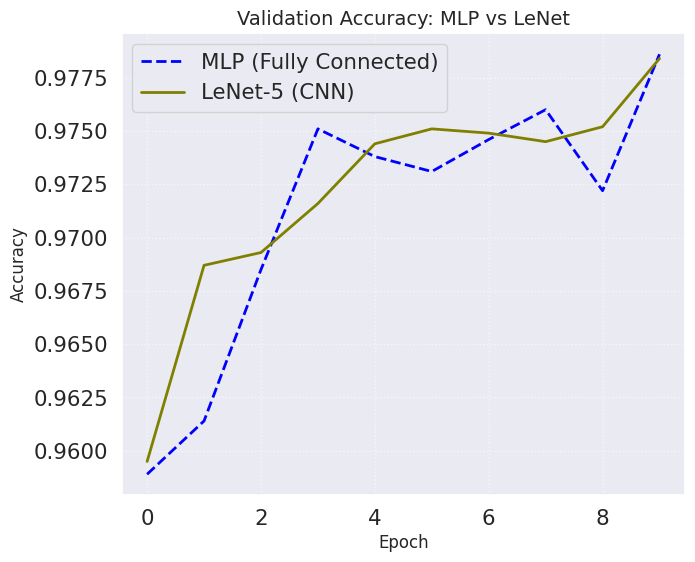

In [68]:
plt.figure(figsize=(16, 6))


plt.subplot(1, 2, 1)

plt.plot(mlp_history['valid'], label='Fully Connected', linestyle='--', color='blue', linewidth=2)
plt.plot(lenet_history['valid'], label='LeNet-5 (CNN)', color='olive', linewidth=2)

plt.title('Validation Accuracy: MLP vs LeNet', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()



plt.show()